In [69]:
import hurricane_net as hn
import datetime
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib
import json

In [2]:
data = hn.data()

hurricane_net 2026-06-18 23:29:39,721 - INFO - root - Loading data with link for ibtracs.ALL.list.v04r01.csv
hurricane_net 2026-06-18 23:30:33,627 - INFO - root - Loading complete. hn.data.all_storms available
hurricane_net 2026-06-18 23:30:33,628 - INFO - root - hn.data.storms has all available storms.


# Peak Season Forecast with In-Depth Example for the Atlantic Basin

In [3]:
# Load storms from the North Atlantic basin
data.filter('NA')
atlantic_storms = data.storms

hurricane_net 2026-06-18 23:30:33,872 - INFO - root - hn.data.storms set to NA basin.


In [4]:
time_col = 'ISO_TIME' # ISO 8601 format
wind_col = 'WMO_WIND' # In knots
# clean data
df = atlantic_storms
df[time_col] = atlantic_storms[time_col].map(lambda x: datetime.datetime.fromisoformat(x))
df = df[df[wind_col] != ' ']

In [5]:
print(f"Training Data Date Range: {min(df[time_col])} to {max(df[time_col])}")

Training Data Date Range: 1851-06-25 00:00:00 to 2025-11-01 06:00:00


In [6]:
# display example of storms for 2025
storms_2025 = df[df[time_col].map(lambda x: x.year) == 2025]
storms_2025[['SID', time_col, 'NAME', 'NATURE', 'LAT', 'LON', wind_col]]

,SID,ISO_TIME,NAME,NATURE,LAT,LON,WMO_WIND
719484,2025173N30302,2025-06-22 00:00:00,ANDREA,DS,30.0,-57.6,20
719486,2025173N30302,2025-06-22 06:00:00,ANDREA,DS,30.5,-57.6,20
719488,2025173N30302,2025-06-22 12:00:00,ANDREA,DS,31.0,-57.6,25
719490,2025173N30302,2025-06-22 18:00:00,ANDREA,DS,31.5,-57.4,25
719492,2025173N30302,2025-06-23 00:00:00,ANDREA,DS,32.0,-57.0,30
...,...,...,...,...,...,...,...
722671,2025294N14290,2025-10-31 06:00:00,MELISSA,TS,34.5,-65.5,75
722673,2025294N14290,2025-10-31 12:00:00,MELISSA,ET,37.7,-62.1,75
722675,2025294N14290,2025-10-31 18:00:00,MELISSA,ET,40.6,-58.9,70
722677,2025294N14290,2025-11-01 00:00:00,MELISSA,ET,43.7,-56.0,70


In [7]:
# filter to entries where there was a severe storm, Category 3 (Saffir-Simpson scale) or higher
threshold = 96 #kt, https://www.nhc.noaa.gov/aboutsshws.php
severe_df = df[df[wind_col].astype('int') > threshold]
# The data quality improved since 1970 and based on that we can use this optional filter
# severe_df = severe_df[severe_df['entry_time'].map(lambda x: x.year) > 1970]
severe_df.sample(5)

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
697050,2021266N10327,2021,82,NA,NA,SAM,2021-09-30 06:00:00,TS,21.0,-58.8,...,,,,12,180,135,150,180,11,320
100204,1909257N18289,1909,48,NA,GM,UNNAMED,1909-09-20 12:00:00,TS,26.9,-90.1,...,,,,,,,,,9,325
689163,2020256N11329,2020,73,NA,NA,TEDDY,2020-09-17 18:00:00,TS,19.7,-53.7,...,,,,12,330,330,300,360,11,315
314108,1965239N11310,1965,79,NA,GM,BETSY,1965-09-08 12:00:00,TS,25.0,-80.6,...,,,,,,,,,9,275
321769,1966265N10325,1966,85,NA,CS,INEZ,1966-09-29 18:00:00,TS,18.1,-72.3,...,,,,,,,,,16,295


hurricane_net 2026-06-18 23:31:23,186 - DEBUG - matplotlib - matplotlib data path: /home/hammad/Documents/hurricane-net/venv/lib/python3.14/site-packages/matplotlib/mpl-data
hurricane_net 2026-06-18 23:31:23,196 - DEBUG - matplotlib - CONFIGDIR=/home/hammad/.config/matplotlib
hurricane_net 2026-06-18 23:31:23,216 - DEBUG - matplotlib - interactive is False
hurricane_net 2026-06-18 23:31:23,217 - DEBUG - matplotlib - platform is linux
hurricane_net 2026-06-18 23:31:23,284 - DEBUG - matplotlib - CACHEDIR=/home/hammad/.cache/matplotlib
hurricane_net 2026-06-18 23:31:23,285 - DEBUG - matplotlib.font_manager - font search path [PosixPath('/home/hammad/Documents/hurricane-net/venv/lib/python3.14/site-packages/matplotlib/mpl-data/fonts/ttf'), PosixPath('/home/hammad/Documents/hurricane-net/venv/lib/python3.14/site-packages/matplotlib/mpl-data/fonts/afm'), PosixPath('/home/hammad/Documents/hurricane-net/venv/lib/python3.14/site-packages/matplotlib/mpl-data/fonts/pdfcorefonts')]
hurricane_net 2

<Axes: xlabel='Calendar Day Number', ylabel='Frequency'>

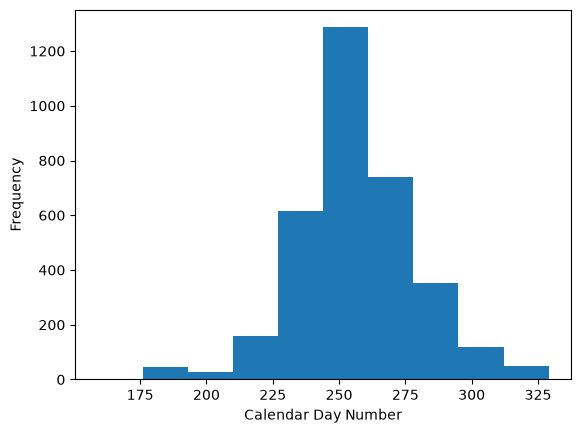

In [9]:
times = severe_df[time_col].map(lambda x: x.timetuple().tm_yday)
times.plot.hist(xlabel="Calendar Day Number")

In [10]:
times.describe()

count    3391.000000
mean      256.027131
std        22.420739
min       159.000000
25%       243.500000
50%       254.000000
75%       270.000000
max       329.000000
Name: ISO_TIME, dtype: float64

In [11]:
def day_count_text(day_count, formatter = '%B %-d'):
  timeline = datetime.datetime(2025, 1, 1) + datetime.timedelta(days = day_count - 1)
  return timeline.strftime(formatter)

In [12]:
# 90% confidence interval
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tstd.html#scipy.stats.tstd
# Calculate statistics like mean and standard deviation
times_mean, times_std = np.mean(times), stats.tstd(times)
print(f"Mean: {round(times_mean)} ({day_count_text(round(times_mean))})")
print(f"Standard Deviation: {round(times_std)} days")

# calculate interval
times_interval = stats.norm.interval(confidence=0.90, loc=times_mean, scale=times_std)
# find start and end of interval and display
times_ci_start = round(times_interval[0])
times_ci_end = round(times_interval[1])
print(f"90% Confidence Interval: {day_count_text(times_ci_start)} to {day_count_text(times_ci_end)}")


Mean: 256 (September 13)
Standard Deviation: 22 days
90% Confidence Interval: August 7 to October 20


In [13]:
lower_bound = 152 # June 1st
upper_bound = 334 # November 30th
scale = upper_bound - lower_bound

# Perform the Kolmogorov-Smirnov test:
# The 'uniform' string or stats.uniform(loc=lower_bound, scale=scale).cdf can be used
statistic, p_value = stats.kstest(times, 'uniform', args=(lower_bound, scale))

print(f"KS Statistic: {statistic}")
print(f"P-value: {p_value}")

# Interpret the results:
# A high p-value (typically > 0.05) suggests that you cannot reject the null hypothesis
# that the sample comes from a uniform distribution.
if p_value > 0.05:
    print("The sample appears to be uniformly distributed.")
else:
    print("The sample does not appear to be uniformly distributed.")

KS Statistic: 0.3440749754521503
P-value: 0.0
The sample does not appear to be uniformly distributed.


# Global Calculation
Utilizing the example above, we can loop through all other basins and calculate a forecast based on the hurricane_net data.

In [76]:
def peak_season_forecast(basin, data, col ='BASIN'):
    '''
    Parameters
    ----------
    basin
      The basin identifier in the IBTrACS
    data
      The loaded data from hurricane_net
    
    Returns
    -------
    basin_peak_season.png
    [ basin : {
        training_range_start
        training_range_end
        mean
        mean_day
        stdev
        ci_start
        ci_end
        ks_stat
        ks_stat_p_value
        uniform_dist_bool
    } ... ]
    '''
    result = {'id': basin, 'col': col}
    storms = data[data[col] == basin]
    time_col = 'ISO_TIME' # ISO 8601 format
    wind_col = 'WMO_WIND' # In knots
    
    # clean data
    df = storms
    df = df[df[wind_col] != ' ']
    df = df[df[time_col] != ' ']
    df[time_col] = storms[time_col].map(lambda x: datetime.datetime.fromisoformat(x) if type(x) == str else x)
    result['training_range_start'] = min(df[time_col]).isoformat()
    result['training_range_end'] = max(df[time_col]).isoformat()
    
    # filter to entries where there was a severe storm, Category 3 (Saffir-Simpson scale) or higher
    threshold = 96 #kt, https://www.nhc.noaa.gov/aboutsshws.php
    severe_df = df[df[wind_col].astype('int') > threshold]
    times = severe_df[time_col].map(lambda x: x.timetuple().tm_yday)
    print(f"Count of severe storm samples: {len(times)} out of {len(df)} cleaned and {len(storms)} total")
    result.update({'count': len(storms), 'count_clean': len(df), 'count_severe': len(times)})

    # calendar day --> month and day (non-leap year)
    def day_count_text(day_count, formatter = '%B %-d'):
      timeline = datetime.datetime(2025, 1, 1) + datetime.timedelta(days = day_count - 1)
      return timeline.strftime(formatter)

    # 90% confidence interval
    # https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tstd.html#scipy.stats.tstd
    # Calculate statistics like mean and standard deviation
    if len(times) < 40: # not enough samples
      print(f'Not enough samples for {basin} at {len(times)}')
      result.update({'error': f'Sample size is less than threshold at {len(times)}'})
      return result
    times_mean, times_std = np.mean(times), stats.tstd(times)
    result['mean'] = round(times_mean)
    result['mean_day'] = day_count_text(round(times_mean))
    result['stdev'] = round(times_std)
    # calculate interval
    times_interval = stats.norm.interval(confidence=0.95, loc=times_mean, scale=times_std)
    # find start and end of interval and display
    times_ci_start = round(times_interval[0])
    times_ci_end = round(times_interval[1])
    result['ci_start'] = day_count_text(times_ci_start)
    result['ci_end'] = day_count_text(times_ci_end)
    print(f"{basin} 95% Confidence Interval: {day_count_text(times_ci_start)} to {day_count_text(times_ci_end)}")
    
    # Perform the Kolmogorov-Smirnov test:
    # The 'uniform' string or stats.uniform(loc=lower_bound, scale=scale).cdf can be used
    lower_bound = 152 # First day of hurricane season: June 1st
    upper_bound = 334 # Last day of hurricane season: November 30th
    scale = upper_bound - lower_bound
    statistic, p_value = stats.kstest(times, 'uniform', args=(lower_bound, scale))
    result['ks_stat'] = statistic
    result['ks_stat_p_value'] = p_value
    # Interpret the results:
    # A high p-value (typically > 0.05) suggests that you cannot reject the null hypothesis
    # that the sample comes from a uniform distribution.
    if p_value > 0.05:
        print("The sample appears to be uniformly distributed.")
        result['uniform_dis_bool'] =  True
    else:
        print("The sample does not appear to be uniformly distributed.")
        result['uniform_dis_bool'] = False

    # Output graph
    ax = times.plot.hist(xlabel="Calendar Day Number")
    ax.figure.savefig(
        f"{basin}_peak_storm_season.png",
        dpi=300,
        bbox_inches='tight')
    ax.clear()

    # return statistics
    return result

In [77]:
basins = {
    'WP' : 'Western North Pacific',
    'NI' : 'North Indian',
    'SI' : 'South Indian',
    'SP' : 'Southern Pacific',
    'NA' : 'North Atlantic',
    'EP' : 'Eastern North Pacific',
    'SA' : 'South Atlantic' # not enough data
}
sub_basins = {
    #MM - missing - no sub basin for this basin (no subbasins provided for WP, SI)
    'CS' : 'Caribbean Sea',
    'GM' : 'Gulf of America',
    'CP' : 'Central Pacific',
    'BB' : 'Bay of Bengal',
    'AS' : 'Arabian Sea',
    'WA' : 'Western Australia',
    'EA' : 'Eastern Australia',
}

hurricane_net 2026-06-18 23:58:19,713 - INFO - root - hn.data.storms has all available storms.
Count of severe storm samples: 1287 out of 28764 cleaned and 242337 total
WP 95% Confidence Interval: May 31 to January 2
The sample does not appear to be uniformly distributed.
Count of severe storm samples: 237 out of 6773 cleaned and 57596 total
NI 95% Confidence Interval: February 22 to January 29
The sample does not appear to be uniformly distributed.
Count of severe storm samples: 939 out of 31779 cleaned and 164405 total
SI 95% Confidence Interval: September 19 to December 13
The sample does not appear to be uniformly distributed.
Count of severe storm samples: 394 out of 14033 cleaned and 68415 total
SP 95% Confidence Interval: September 20 to October 7
The sample does not appear to be uniformly distributed.
Count of severe storm samples: 3391 out of 55422 cleaned and 126461 total
NA 95% Confidence Interval: July 31 to October 27
The sample does not appear to be uniformly distributed.

/tmp/ipykernel_156043/453051991.py:54: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  times_mean, times_std = np.mean(times), stats.tstd(times)


TypeError: type NaTType doesn't define __round__ method

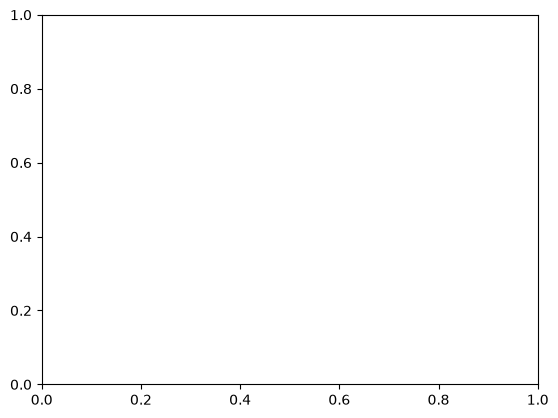

In [78]:
data.filter('all')
results = []
for basin in basins:
    result = peak_season_forecast(basin, data.storms)
    results.append(result)
for sb in sub_basins:
    result = peak_season_forecast(sb, data.storms, col='SUBBASIN')
    results.append(result)
df = pd.DataFrame(results)
df.to_csv('peak_severe_season.csv')